## Loading Packages, Functions and Data

In [1]:
# import custom functions and required packages from secondary file
from project_functions import *
# turn off warnings
warnings.filterwarnings("ignore")

In [2]:
# Runtime: ~ 3 minutes 
# path to downloaded all match data [UPDATE AS REQUIRED]
path = "/Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/"
game_ids = ["COM-000001_DFL-MAT-J03WMX", "COM-000001_DFL-MAT-J03WN1",
            "COM-000002_DFL-MAT-J03WPY", "COM-000002_DFL-MAT-J03WOH",
            "COM-000002_DFL-MAT-J03WQQ", "COM-000002_DFL-MAT-J03WOY",
            "COM-000002_DFL-MAT-J03WR9"]
# create dictionary of all 7 game objects
game_data = {}
for id in game_ids:
    game = import_match_data(id, path)
    game_data.update({id: game})

Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WMX.xml

100%|██████████| 7590415/7590415 [00:09<00:00, 823516.33it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WN1.xml

100%|██████████| 7099405/7099405 [00:08<00:00, 833813.01it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WPY.xml

...

100%|██████████| 6442009/6442009 [00:08<00:00, 803725.66it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOY.xml

100%|██████████| 6556773/6556773 [00:10<00:00, 627433.33it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WR9.xml

100%|██████████| 6753373/6753373 [00:08<00:00, 776865.91it/s] 


In [3]:
import pickle
pass_event_consol = pickle.load(open('consol.pkl', 'rb'))

# column dictionary for plotting and tables
column_dict = {'outp2inp':"OP2IP", 'd2co_ts_max_dec':"$\\text{CO}_{\\text{MD}}$", 'd2tloc_ts_range':"$\\text{TLoC}_{r}$", "d2co_ts_max_dec_ind":"$\\text{CO}_{\\text{MD}>0}$",
               'd2tlac_ts_range':"$\\text{TLaC}_{r}$",'d2tloc_ts_ae':"$\\text{TLoC}_{\\text{AE}}$", 'd2tlac_ts_ae':"$\\text{TLaC}_{\\text{AE}}$",
               'hp_pass':"$\\text{HP}$", 'pressure_ts_drop_time':"$\\text{P}_{\\text{DT}}$",'sa_ts_max_inc':"$\\text{SA}_{\\text{MI}}$",
               'sp_ts_max_inc':"$\\text{SP}_{\\text{MI}}$", 'sa_ts_no_inc':"$\\text{SA}_{\\text{NI}}$",
               'sp_ts_no_inc':"$\\text{SA}_{\\text{MI}}$",'one_two':"$\\text{OT}$", "hp2lp":"HP2LP"}

# metric column names
col_names = ["outp2inp", "d2co_ts_max_dec_ind", "d2co_ts_max_dec", "d2tloc_ts_range", "d2tlac_ts_range",
             "d2tloc_ts_ae", "d2tlac_ts_ae", "hp2lp", 'sa_ts_no_inc', "sa_ts_max_inc",  'sp_ts_no_inc',
             "sp_ts_max_inc", "one_two"]

# remove uncertain frames (if not already removed)
pass_event_consol_is = pass_event_consol[pass_event_consol["certain"]==True]
post_pass_emb = pass_event_consol_is[col_names]
post_pass_emb

# binary variable columns
bin_cols = ["outp2inp", "d2co_ts_max_dec_ind", "h2lp",'sa_ts_no_inc', 'sp_ts_no_inc', "one_two"]
# continuous variable columns
cont_cols = ["d2co_ts_max_dec", "d2tloc_ts_range", "d2tlac_ts_range",
             "d2tloc_ts_ae", "d2tlac_ts_ae",
             "sa_ts_max_inc", "sp_ts_max_inc"]
# role dictionary
role_dict = {"goalkeeper": "Goalkeeper", "defender": "Defender", "midfielder":"Midfielder", "forward":"Forward"}

# Consolidated Post-Pass Embedding

In [4]:
column_dict = {'outp2inp':"OP2IP", 'd2co_ts_max_dec':"$\\text{CO}_{\\text{MD}}$", 'd2tloc_ts_range':"$\\text{TLoC}_{r}$", "d2co_ts_max_dec_ind":"$\\text{CO}_{\\text{MD}>0}$",
               'd2tlac_ts_range':"$\\text{TLaC}_{r}$",'d2tloc_ts_ae':"$\\text{TLoC}_{\\text{AE}}$", 'd2tlac_ts_ae':"$\\text{TLaC}_{\\text{AE}}$",
               'hp_pass':"$\\text{HP}$", 'pressure_ts_drop_time':"$\\text{P}_{\\text{DT}}$",'sa_ts_max_inc':"$\\text{SA}_{\\text{MI}}$",
               'sp_ts_max_inc':"$\\text{Frob}_{\\text{MI}}$", 'sa_ts_no_inc':"$\\text{SA}_{\\text{NI}}$",
               'sp_ts_no_inc':"$\\text{Frob}_{\\text{NI}}$",'one_two':"$\\text{OT}$", "hp2lp":"HP2LP", "m2o":"M2O"}
# post-pass embedding
col_names = ["outp2inp", "m2o", "d2tloc_ts_range", "d2tlac_ts_range",
             "d2tloc_ts_ae", "d2tlac_ts_ae", "hp2lp", 'sa_ts_no_inc', "sa_ts_max_inc",  'sp_ts_no_inc',
             "sp_ts_max_inc", "one_two"]
# remove uncertain frames (if not already removed)
pass_event_consol_is = pass_event_consol[pass_event_consol["certain"]==True]
post_pass_emb = pass_event_consol_is[col_names]
post_pass_emb
# binary variable columns
bin_cols = ["outp2inp", "m2o", "hp2lp",'sa_ts_no_inc', 'sp_ts_no_inc', "one_two"]
# continuous variable columns
cont_cols = ["d2tloc_ts_range", "d2tlac_ts_range",
             "d2tloc_ts_ae", "d2tlac_ts_ae",
             "sa_ts_max_inc", "sp_ts_max_inc"]

## Analyse the continuous variables shape 

To normalize the variables fit and apply box-cox transformations.

In [5]:
import scipy
import scipy.stats as stats

In [6]:
# apply box cox to continuous variables
post_pass_emb_t = post_pass_emb.copy()
box_cox_lambda = {}
for col in cont_cols:
    box_cox_t, lamb = stats.boxcox(post_pass_emb[col][~post_pass_emb[col].isna()])
    box_cox_lambda[col] = lamb
    post_pass_emb_t.loc[~post_pass_emb[col].isna(), col] =box_cox_t
    

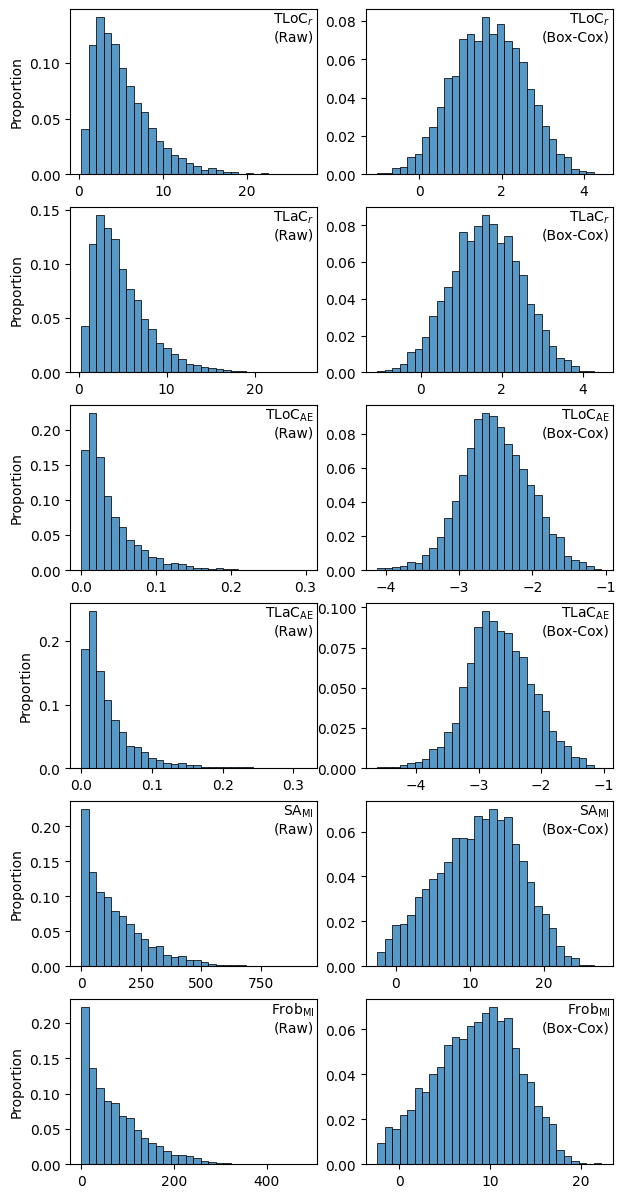

In [7]:

## appendix box-cox normality
fig, ax = plt.subplots(6, 2, figsize=(7,15))

for ind, col in enumerate(cont_cols):
    sns.histplot(post_pass_emb[col][~post_pass_emb[col].isna()], bins=30, ax=ax[ind,0], stat="proportion")
    sns.histplot(post_pass_emb_t[col][~post_pass_emb_t[col].isna()], bins=30, ax=ax[ind,1],stat="proportion")
    ax[ind,1].set_ylabel("")
    ax[ind,0].set_xlabel(""); ax[ind,1].set_xlabel("")
    ax[ind,0].text(0.99, 0.99, f"{column_dict[col]}\n(Raw)", transform=ax[ind,0].transAxes, horizontalalignment="right", verticalalignment="top")
    ax[ind,1].text(0.99, 0.99, f"{column_dict[col]}\n(Box-Cox)", transform=ax[ind,1].transAxes, horizontalalignment="right", verticalalignment="top")
plt.show()

In [8]:
# # attempt to normalize variables by sqrt transformation
# post_pass_emb = post_pass_emb.map(np.sqrt, dtype="float64")
# post_pass_emb

## Correlation between variables
* Spearman Rank between two continuous
* Phi between two binary
* Point biserial correlation

In [9]:
post_pass_emb_t.corr(method="pearson")

,outp2inp,m2o,d2tloc_ts_range,d2tlac_ts_range,d2tloc_ts_ae,d2tlac_ts_ae,hp2lp,sa_ts_no_inc,sa_ts_max_inc,sp_ts_no_inc,sp_ts_max_inc,one_two
outp2inp,1.000000,0.061206,0.045182,0.092159,-0.036567,-0.058879,0.012862,0.044019,-0.020741,0.045034,-0.022914,-0.034870
m2o,0.061206,1.000000,0.115894,0.130192,0.045634,0.016866,-0.153496,-0.015739,0.000244,0.001101,0.020640,0.045344
d2tloc_ts_range,0.045182,0.115894,1.000000,0.124745,-0.114563,0.053635,0.066304,0.013918,0.028925,-0.001157,0.018005,-0.015527
d2tlac_ts_range,0.092159,0.130192,0.124745,1.000000,0.069413,-0.148248,0.083803,0.014521,0.011566,0.015194,-0.017453,0.002867
d2tloc_ts_ae,-0.036567,0.045634,-0.114563,0.069413,1.000000,0.173559,0.057587,0.001633,-0.014271,-0.008765,-0.021749,0.087844
d2tlac_ts_ae,-0.058879,0.016866,0.053635,-0.148248,0.173559,1.000000,0.046104,-0.015938,0.011095,-0.005201,0.041636,0.085444
hp2lp,0.012862,-0.153496,0.066304,0.083803,0.057587,0.046104,1.000000,0.031751,0.022848,0.046271,0.018930,-0.069443
sa_ts_no_inc,0.044019,-0.015739,0.013918,0.014521,0.001633,-0.015938,0.031751,1.000000,NaN,0.679421,-0.319178,-0.028114
sa_ts_max_inc,-0.020741,0.000244,0.028925,0.011566,-0.014271,0.011095,0.022848,NaN,1.000000,-0.318705,0.774918,-0.055337
sp_ts_no_inc,0.045034,0.001101,-0.001157,0.015194,-0.008765,-0.005201,0.046271,0.679421,-0.318705,1.000000,NaN,-0.042274


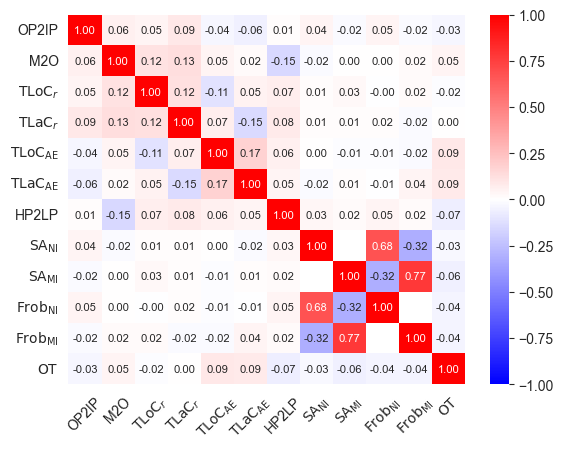

In [10]:
# compare correlation
sns.set_style("white")
sns.heatmap(post_pass_emb_t.rename(columns=column_dict).corr(method="pearson"), vmin=-1, vmax=1,cmap="bwr",annot=True, fmt=".2f", annot_kws={"fontsize":8})
plt.xticks(rotation=45)
plt.show()

## Set Piece Skew

In [11]:
# passes by set piece
pass_event_consol_is["set_piece"].value_counts()

set_piece
no_set_piece    5028
throw_in         272
free_kick        147
goal_kick         99
corner_kick       42
kick_off          19
Name: count, dtype: int64

In [12]:
# Kruskal Wallis test for continuous variables
set_piece_list = pass_event_consol_is["set_piece"].unique()

kw_set_piece = pd.DataFrame()
for col in cont_cols:
    set_piece_df = [post_pass_emb[pass_event_consol_is["set_piece"]==set_piece][col] for set_piece in set_piece_list]
    test = stats.kruskal(*set_piece_df,nan_policy="omit")
    F, p = test.statistic, test.pvalue
    kw_set_piece = pd.concat([kw_set_piece, pd.DataFrame(np.array([F,p])[None,:],columns=["H", "p"],index =[col])], axis=0)
    
kw_set_piece

,H,p
d2tloc_ts_range,79.933251,8.666033e-16
d2tlac_ts_range,46.369395,7.637713e-09
d2tloc_ts_ae,27.614657,4.328719e-05
d2tlac_ts_ae,70.828702,6.888698e-14
sa_ts_max_inc,55.389736,1.085269e-10
sp_ts_max_inc,41.810321,6.434608e-08


In [13]:
# Dunn post hoc tests
matrix = pd.DataFrame()
for col in cont_cols:
    set_piece_df = [post_pass_emb[(pass_event_consol_is["set_piece"]==set_piece)&(~pass_event_consol_is[col].isna())][col] for set_piece in set_piece_list]
    nsp = sp.posthoc_dunn(set_piece_df, p_adjust=None).iloc[:,0]
    matrix = pd.concat([matrix, nsp],axis=1)
matrix.columns = cont_cols
matrix

,d2tloc_ts_range,d2tlac_ts_range,d2tloc_ts_ae,d2tlac_ts_ae,sa_ts_max_inc,sp_ts_max_inc
1,1.000000e+00,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00
2,6.603421e-10,0.000001,0.063145,0.000018,3.928324e-02,3.758353e-01
3,4.034579e-02,0.000454,0.150400,0.000177,2.260361e-01,8.919887e-01
4,3.345862e-03,0.133415,0.129078,0.000012,2.069113e-05,9.003958e-03
5,5.205134e-01,0.365714,0.116178,0.353254,1.148888e-07,3.511079e-08
6,2.702619e-07,0.008092,0.000016,0.000001,9.058666e-02,2.796861e-02


In [14]:
# test results (Bonferonni correction)
matrix < (0.05/(5*6))

,d2tloc_ts_range,d2tlac_ts_range,d2tloc_ts_ae,d2tlac_ts_ae,sa_ts_max_inc,sp_ts_max_inc
1,False,False,False,False,False,False
2,True,True,False,True,False,False
3,False,True,False,True,False,False
4,False,False,False,True,True,False
5,False,False,False,False,True,True
6,True,False,True,True,False,False


Now for **binary** variables...

In [15]:
# overall distribution by set piece type
pass_event_consol_is.groupby(["set_piece"])[bin_cols].agg([np.sum, len, lambda x: np.sum(x)/len(x)])

outp2inp                   m2o                  hp2lp        \
                  sum   len <lambda_0>  sum   len <lambda_0>   sum   len   
set_piece                                                                  
corner_kick         5    42   0.119048    2    42   0.047619     0    42   
free_kick           9   147   0.061224    9   147   0.061224     3   147   
goal_kick           5    99   0.050505    1    99   0.010101     0    99   
kick_off            1    19   0.052632    9    19   0.473684     0    19   
no_set_piece      484  5028   0.096261  394  5028   0.078361  1281  5028   
throw_in           28   272   0.102941   43   272   0.158088     3   272   

                        sa_ts_no_inc                  sp_ts_no_inc        \
             <lambda_0>          sum   len <lambda_0>          sum   len   
set_piece                                                                  
corner_kick    0.000000            5    42   0.119048            9    42   
free_kick      0.020408           16   147   0.108844           24   147   
goal_kick      0.000000           25    99   0.252525           20    99   
kick_off       0.000000            0    19   0.000000            1    19   
no_set_piece   0.254773         1342  5028   0.266905         1312  5028   
throw_in       0.011029           89   272   0.327206           94   272   

                        one_two                   
             <lambda_0>     sum   len <lambda_0>  
set_piece                                         
corner_kick    0.214286       5    42   0.119048  
free_kick      0.163265      14   147   0.095238  
goal_kick      0.202020       7    99   0.070707  
kick_off       0.052632       1    19   0.052632  
no_set_piece   0.260939     564  5028   0.112172  
throw_in       0.345588      55   272   0.202206

In [16]:
# exclude corners and kick-offs as <5 expected frequencies
# chi square test
no_c_ko = pass_event_consol_is[~pass_event_consol_is["set_piece"].isin(["kick_off","corner_kick"])]

chisq_set_piece= pd.DataFrame()

for col in bin_cols:
    observed = pd.crosstab(no_c_ko["set_piece"], no_c_ko[col])
    chi2_test = stats.chi2_contingency(observed)
    F, p = chi2_test.statistic, chi2_test.pvalue
    chisq_set_piece = pd.concat([chisq_set_piece, pd.DataFrame(np.array([F,p])[None,:],columns=["F", "p"],index =[col])], axis=0)
chisq_set_piece.rename(index=column_dict)

,F,p
OP2IP,4.527850,2.098195e-01
M2O,29.764613,1.546694e-06
HP2LP,155.990770,1.343637e-33
$\text{SA}_{\text{NI}}$,23.951266,2.557208e-05
$\text{Frob}_{\text{NI}}$,19.128743,2.571420e-04
$\text{OT}$,23.113768,3.823694e-05


In [17]:
# post hoc chi square tests
chisq_set_piece= pd.DataFrame()

for col in bin_cols:
    p_vals = []
    for set_piece in ['throw_in', 'goal_kick','free_kick']:
        no_c_ko_filter = no_c_ko[no_c_ko["set_piece"].isin([set_piece, "no_set_piece"])]
        observed = pd.crosstab(no_c_ko_filter["set_piece"], no_c_ko_filter[col])
        chi2_test = stats.chi2_contingency(observed)
        F, p = chi2_test.statistic, chi2_test.pvalue
        p_vals += [p]
    chisq_set_piece = pd.concat([chisq_set_piece, pd.DataFrame(np.array(p_vals)[None,:],columns=['throw_in', 'goal_kick','free_kick'],index =[col])], axis=0)
chisq_set_piece.rename(index=column_dict).T

,OP2IP,M2O,HP2LP,$\text{SA}_{\text{NI}}$,$\text{Frob}_{\text{NI}}$,$\text{OT}$
throw_in,0.796498,0.000006,1.236477e-19,0.034710,0.002617,0.000011
goal_kick,0.173159,0.019702,1.336224e-08,0.837047,0.226993,0.255363
free_kick,0.199236,0.543105,1.682273e-10,0.000027,0.010119,0.610289


In [18]:
# test results with bonferonni correction
chisq_set_piece.rename(index=column_dict).T<0.05/18

,OP2IP,M2O,HP2LP,$\text{SA}_{\text{NI}}$,$\text{Frob}_{\text{NI}}$,$\text{OT}$
throw_in,False,True,True,False,True,True
goal_kick,False,False,True,False,False,False
free_kick,False,False,True,True,False,False


# Gower Distance

In [19]:
# instead of 0 use median non-zero
post_pass_emb.loc[post_pass_emb['sa_ts_no_inc'], 'sa_ts_max_inc'] = post_pass_emb.loc[post_pass_emb['sa_ts_no_inc']==False, 'sa_ts_max_inc'].median()
post_pass_emb.loc[post_pass_emb['sp_ts_no_inc'], 'sp_ts_max_inc'] = post_pass_emb.loc[post_pass_emb['sp_ts_no_inc']==False, 'sp_ts_max_inc'].median()

# instead of 0 use median non-zero
pass_event_consol_is.loc[pass_event_consol_is['sa_ts_no_inc'], 'sa_ts_max_inc'] = pass_event_consol_is.loc[pass_event_consol_is['sa_ts_no_inc']==False, 'sa_ts_max_inc'].median()
pass_event_consol_is.loc[pass_event_consol_is['sp_ts_no_inc'], 'sp_ts_max_inc'] = pass_event_consol_is.loc[pass_event_consol_is['sp_ts_no_inc']==False, 'sp_ts_max_inc'].median()

# gower distance embedding
emb_gower_dist = gower.gower_matrix(post_pass_emb, cat_features=[True,True,False,False,False,False,True,True,False,True,False,True])
emb_gower_dist

array([[0.        , 0.32454094, 0.30215627, ..., 0.04875097, 0.16264552,
        0.22257704],
       [0.32454094, 0.        , 0.19652942, ..., 0.29383603, 0.19164786,
        0.1181496 ],
       [0.30215627, 0.19652942, 0.        , ..., 0.3113    , 0.20850588,
        0.27776003],
       ...,
       [0.04875097, 0.29383603, 0.3113    , ..., 0.        , 0.13415726,
        0.2254985 ],
       [0.16264552, 0.19164786, 0.20850588, ..., 0.13415726, 0.        ,
        0.1239449 ],
       [0.22257704, 0.1181496 , 0.27776003, ..., 0.2254985 , 0.1239449 ,
        0.        ]], shape=(5607, 5607), dtype=float32)

### k-Medoid Clustering

In [20]:
# k-medoids

import kmedoids
sil_scores = []
med_sil_scores = []
k_values = [i for i in range(2,21,1)]
for k in k_values:
    kmed = kmedoids.pam(emb_gower_dist, k, random_state=1234)
    sil_scores += [kmedoids.silhouette(emb_gower_dist, kmed.labels)[0]]
    med_sil_scores += [kmedoids.medoid_silhouette(emb_gower_dist, kmed.labels)[0]]

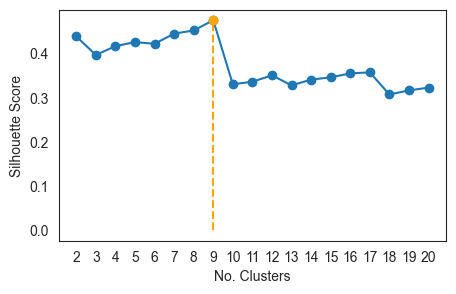

Max Score: 0.47567704911880426


In [21]:
plt.figure(figsize=(5,3))
plt.plot(k_values, sil_scores, marker='o', color='tab:blue')
plt.ylabel("Silhouette Score"); plt.xlabel("No. Clusters")
plt.vlines(x=k_values[np.argmax(sil_scores)], ymin=0, ymax=sil_scores[np.argmax(sil_scores)], linestyles="dashed", colors="orange")
plt.scatter(x=k_values[np.argmax(sil_scores)], y=sil_scores[np.argmax(sil_scores)], c="orange", zorder=3)
plt.xticks(k_values); plt.show()
print("Max Score:", np.max(sil_scores))

# opt clustering
kmed_opt = kmedoids.pam(emb_gower_dist, k_values[np.argmax(sil_scores)], random_state=1234, max_iter=1000)

### Cluster Analysis

In [22]:
# cluster assignment
pass_event_consol_is["cluster"] = kmed_opt.labels +1
pass_event_consol_is["cluster"].value_counts()

# quantitative continuous variable analysis by cluster
pd.set_option('display.max_columns', None)
pass_event_consol_is.groupby(["cluster"])[cont_cols].agg([np.nanmedian,  lambda x: np.quantile(x,0.25), lambda x: np.quantile(x,0.75)])

d2tloc_ts_range                       d2tlac_ts_range             \
              nanmedian <lambda_0> <lambda_1>       nanmedian <lambda_0>   
cluster                                                                    
1              4.198889   2.604000   6.707000           3.829   2.434444   
2              4.304000   2.510000   7.203333           3.996   2.439000   
3              5.001000   3.256000   7.508000           4.631   2.909000   
4              3.480000   2.324500   5.496500           3.361   2.202000   
5              6.603000   4.033000   8.920000           5.582   3.732000   
6              5.096667   3.080000   7.151000           4.470   2.996000   
7              4.429000   2.629000   6.899000           4.040   2.543000   
8              4.098000   2.709000   6.361000           5.065   2.979000   
9              3.793000   2.386167   5.866000           3.672   2.268500   

                   d2tloc_ts_ae                       d2tlac_ts_ae             \
        <lambda_1>    nanmedian <lambda_0> <lambda_1>    nanmedian <lambda_0>   
cluster                                                                         
1         5.864444     0.023355   0.012270   0.046917     0.023720   0.012745   
2         6.499000     0.024452   0.012879   0.046621     0.024412   0.012154   
3         6.957500     0.027766   0.013559   0.058776     0.031109   0.015509   
4         5.301000     0.036092   0.020220   0.063993     0.036234   0.017443   
5         8.346000     0.032092   0.015069   0.065906     0.025530   0.012845   
6         7.617000     0.035426   0.016890   0.064998     0.024592   0.012131   
7         6.645556     0.025885   0.014993   0.048889     0.021170   0.010934   
8         7.129000     0.021094   0.011234   0.040203     0.018327   0.010327   
9         6.278000     0.025649   0.014471   0.047036     0.024391   0.012717   

                   sa_ts_max_inc                         sp_ts_max_inc  \
        <lambda_1>     nanmedian  <lambda_0>  <lambda_1>     nanmedian   
cluster                                                                  
1         0.047429     117.70845   44.387800  210.418800     61.241576   
2         0.049833     104.60840  104.608400  104.608400     53.284307   
3         0.055785     113.21350   43.814625  230.108050     56.502568   
4         0.062126     102.73700   47.222325  177.287100     53.603254   
5         0.055856     104.60840   43.113750  224.331300     58.608871   
6         0.049858     104.60840  104.608400  104.608400     53.284307   
7         0.044186     104.60840  104.608400  104.608400      7.209290   
8         0.036767     119.01705   43.778000  228.731850     56.605203   
9         0.044369      13.80370    3.104000   39.937875     53.284307   

                                
        <lambda_0>  <lambda_1>  
cluster                         
1        23.478980  109.247308  
2        53.284307   53.284307  
3        25.679632  115.615280  
4        25.499176   89.799980  
5        21.425123  109.792211  
6        53.284307   53.284307  
7         1.162086   21.170809  
8        16.631425  124.007041  
9        53.284307   53.284307

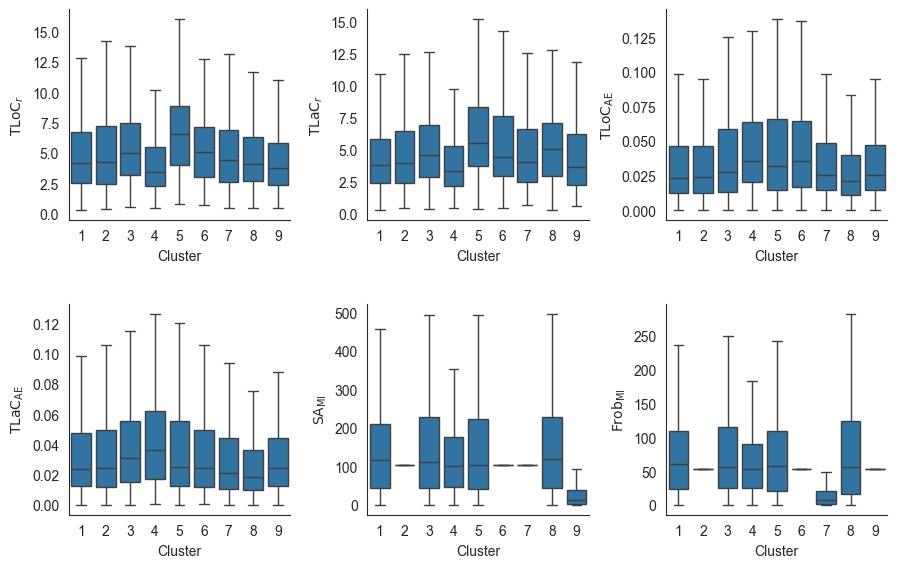

In [23]:
# continuous variable distribution within clusters
melted = pass_event_consol_is.melt(id_vars=["cluster"], value_vars=cont_cols, var_name="metric", value_name="value")
melted["metric"] = melted["metric"].replace(column_dict)
clusters = melted["cluster"].unique().sort()

melted["cluster"] = pd.Categorical(
    melted["cluster"],
    categories=clusters,
    ordered=True
)
g = sns.catplot(data=melted, x="cluster", y="value", col="metric", kind="box", col_wrap=3,height=3, sharey=False, showfliers=False,sharex=False,order=clusters)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    metric = ax.get_title()
    ax.set_ylabel(metric)
    ax.set_title("")
    ax.set_xlabel("Cluster")
g.figure.subplots_adjust(wspace=0.35, hspace=0.4)
plt.show()

In [24]:
# binary variable distribution between clusters
pass_event_consol_is.groupby(["cluster"])[bin_cols].agg([lambda x: np.sum(x), lambda x: len(x) - np.sum(x), lambda x: np.sum(x)/len(x)])

outp2inp                              m2o                        \
        <lambda_0> <lambda_1> <lambda_2> <lambda_0> <lambda_1> <lambda_2>   
cluster                                                                     
1                0       2113   0.000000          0       2113   0.000000   
2              103        730   0.123649         91        742   0.109244   
3               38        749   0.048285          2        785   0.002541   
4                8        399   0.019656         14        393   0.034398   
5               28        273   0.093023        301          0   1.000000   
6               36        293   0.109422          2        327   0.006079   
7               32        273   0.104918         11        294   0.036066   
8              265          0   1.000000         20        245   0.075472   
9               22        245   0.082397         17        250   0.063670   

             hp2lp                       sa_ts_no_inc                        \
        <lambda_0> <lambda_1> <lambda_2>   <lambda_0> <lambda_1> <lambda_2>   
cluster                                                                       
1                0       2113   0.000000            0       2113   0.000000   
2                0        833   0.000000          833          0   1.000000   
3              787          0   1.000000            2        785   0.002541   
4               31        376   0.076167           14        393   0.034398   
5                2        299   0.006645            7        294   0.023256   
6              329          0   1.000000          313         16   0.951368   
7               56        249   0.183607          305          0   1.000000   
8               43        222   0.162264            3        262   0.011321   
9               39        228   0.146067            0        267   0.000000   

        sp_ts_no_inc                          one_two                        
          <lambda_0> <lambda_1> <lambda_2> <lambda_0> <lambda_1> <lambda_2>  
cluster                                                                      
1                  0       2113   0.000000          0       2113   0.000000  
2                833          0   1.000000         80        753   0.096038  
3                 39        748   0.049555         28        759   0.035578  
4                  4        403   0.009828        407          0   1.000000  
5                  7        294   0.023256         46        255   0.152824  
6                304         25   0.924012         28        301   0.085106  
7                  0        305   0.000000         25        280   0.081967  
8                  6        259   0.022642         10        255   0.037736  
9                267          0   1.000000         22        245   0.082397

In [25]:
# total row
pass_event_consol_is.groupby(lambda _ :True)[bin_cols].agg([lambda x: np.sum(x), lambda x: len(x) - np.sum(x), lambda x: np.sum(x)/len(x)])

outp2inp                              m2o                        \
     <lambda_0> <lambda_1> <lambda_2> <lambda_0> <lambda_1> <lambda_2>   
True        532       5075   0.094881        458       5149   0.081684   

          hp2lp                       sa_ts_no_inc                        \
     <lambda_0> <lambda_1> <lambda_2>   <lambda_0> <lambda_1> <lambda_2>   
True       1287       4320   0.229535         1477       4130   0.263421   

     sp_ts_no_inc                          one_two                        
       <lambda_0> <lambda_1> <lambda_2> <lambda_0> <lambda_1> <lambda_2>  
True         1460       4147   0.260389        646       4961   0.115213

### Role Level Analysis Representation

stat: 332.8772623419683 p-value: 3.791061567498562e-56


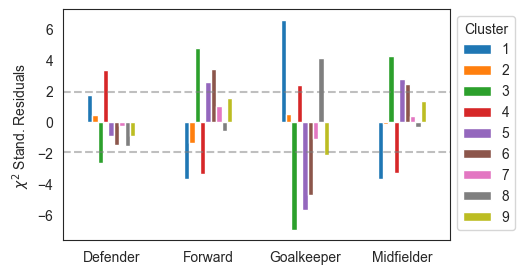

In [26]:
role_dict = {"goalkeeper": "Goalkeeper", "defender": "Defender", "midfielder":"Midfielder", "forward":"Forward"}
# role breakdown by cluster
ct = pd.crosstab(pass_event_consol_is["cluster"], pass_event_consol_is["role"].map(lambda x: role_dict[x]))

# chi square test
chi_test_role = stats.chi2_contingency(ct)
# test reuslts
print("stat:", chi_test_role.statistic, "p-value:", chi_test_role.pvalue)
# expected frequencies
exp = chi_test_role.expected_freq
# plot standardized residuals
ax = ((ct-exp)/np.sqrt(exp)).T.plot.bar(figsize=(5,3))
plt.ylabel("$\chi^2$ Stand. Residuals")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Cluster", bbox_to_anchor=(1,1))
plt.hlines(y=[-1.96,1.96],xmin=-0.5, xmax=10, linestyle="dashed", colors="grey", alpha=0.5) 
plt.show()

### Player Level Analysis

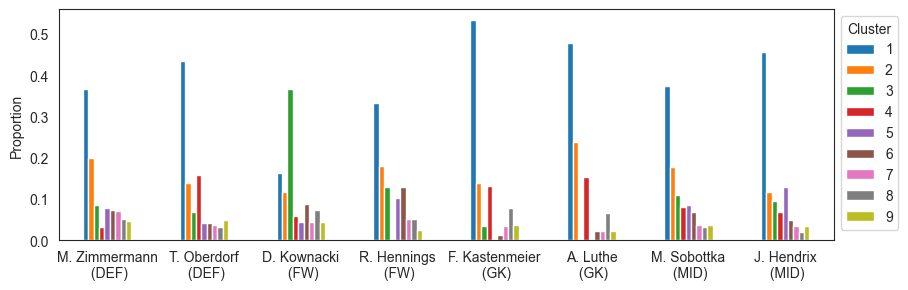

In [27]:
# for each role obtain top two players with most passes
pass_event_consol_is["play_role"] = pass_event_consol_is.apply(lambda x: game_data[x["match"]].player_column_id_to_full_name(game_data[x["match"]].player_id_to_column_id(x["player_id"])) + f" ({role_dict[x["role"]]})",axis=1)

players = (pass_event_consol_is.groupby(["role", "play_role"])
      .size()
      .reset_index(name="count")
      .sort_values(["role", "count"], ascending=[True, False])
      .groupby("role")
      .head(2)
)["play_role"].values

# role breakdown by cluster
ct = pd.crosstab(pass_event_consol_is["cluster"], pass_event_consol_is.apply(lambda x: game_data[x["match"]].player_column_id_to_full_name(game_data[x["match"]].player_id_to_column_id(x["player_id"])) + f" ({role_dict[x["role"]]})",axis=1))

players_dict = {'Matthias Jürgen Zimmermann (Defender)': 'M. Zimmermann\n (DEF)',
       'Tim Christopher Oberdorf (Defender)' : 'T. Oberdorf\n (DEF)',
       'Dawid Igor Kownacki (Forward)' : 'D. Kownacki\n (FW)', 'Rouwen Hennings (Forward)' : 'R. Hennings\n (FW)',
       'Florian Kastenmeier (Goalkeeper)':  'F. Kastenmeier\n (GK)', 'Andreas Luthe (Goalkeeper)':  'A. Luthe\n (GK)',
       'Marcel Sobottka (Midfielder)':  'M. Sobottka\n (MID)',
       'Jorrit Petrus Carolina Hendrix (Midfielder)': 'J. Hendrix\n (MID)'}

cluster_prop = ct.div(ct.sum(axis=0), axis=1)
cluster_prop[players].rename(columns=players_dict).T.plot.bar(figsize=(10,3))
plt.ylabel("Proportion")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Cluster", bbox_to_anchor=(1,1))
plt.show()